В данном файле реализован и протестирован критерий согласия, основанный на следующем "расстоянии" между функциями распределения:

$$\rho_{PQ-PQ}(F, F_0) = \int_{0}^{1} \left( F(F_0^{-1}(x)) - F_0(F^{-1}(x)) \right)^2 dx$$

С помощью математических выкладок можно показать:

Eсли $X_1,...,X_n \sim F$, $F_n(x) = \sum_{i=0}^n I(X_i ≤ x)$ - ЭФР, то $\rho_{PQ-PQ}(F, F_n)$ не зависит от F, т.е. имеет конкретное распределение.

Это распределение сложно найти, но, зная утвердение выше, мы можем методом Монте-Карло сделать большую теоретическую выборку из этого распределения, и сравнивать значения этой величины на практике со значениями этой выборки.

Ниже представлена реализация этого расстояния, реализация метода Монте-Карло и сравнение построенного критерия с известными ранее.

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as sts
import matplotlib.pyplot as plt

In [ ]:
#-----------------Статистики для критериев-----------------

dist_functions = {
        'normal': sts.norm,
        'uniform': sts.uniform,
        'exponential': sts.expon,
        'poisson': sts.poisson,
        'binomial': sts.binom,
        'gamma': sts.gamma,
        'cauchy': sts.cauchy
    }


def distribution(dist, loc = 0, scale = 1, a = 1):
  if dist not in dist_functions: return -1
  if dist == 'gamma': return dist_functions[dist](a=a, loc = loc, scale = scale)
  return dist_functions[dist](loc = loc, scale = scale)


def PQ_PQ(sample, dist):

  n = len(sample)
  m = n+1
  first = [dist.cdf(x) for x in sample]
  first.sort()
  #print(first)
  second = [k/n for k in range(n+1)]
  i, j = 0, 0 #условно номера левого конца
  s = 0

  while i<n and j<m:
    if first[i]<=second[j]:
      if i+1<n and first[i+1]<second[j]: #значит концы first[i] first[i+1]
        #print(f"1, i: {i}, j: {j}, len(first): {len(first)}, len(second): {len(second)}")
        s+=(first[i+1]-first[i])*(((i+1)/n-first[j-1])**2)
        i+=1
      else: #значит концы first[i] second[j]
        #print(f"2, i: {i}, j: {j}, len(first): {len(first)}, len(second): {len(second)}")
        s+=(second[j]-first[i])*(((i+1)/n-first[j-1])**2)
        i+=1
    else:
      if j+1<m and second[j+1]<first[j]: #значит концы second[j] second[j+1]
        #print(f"3, i: {i}, j: {j}, len(first): {len(first)}, len(second): {len(second)}")
        s+=(second[j+1]-second[j])*(((i)/n-first[j])**2)
        j+=1
      else: #значит концы second[j] first[i]
        #print(f"4, i: {i}, j: {j}, len(first): {len(first)}, len(second): {len(second)}")
        s+=(first[i]-second[j])*(((i)/n-first[j])**2)
        j+=1
  return n*s


def CvM(sample, dist):

    sample = sorted(sample)
    l= len(sample)
    t = 1/(12*l)

    for i in range(l):
        t += ((2*i-1)/(2*l)-dist.cdf(sample[i]))**2

    return t

def AD(sample, dist):

    sample = sorted(sample)
    l = len(sample)
    t = -l

    for i in range(l):
        t -= (2*(i+1)-1)/l * (np.log(dist.cdf(sample[i])) +
                              np.log(1 - dist.cdf(sample[l-1-i])))

    return t

def Kolm(sample, dist):

    sample = sorted(sample)
    l = len(sample)
    T = np.zeros(2*l)

    for i in range(l):
        T[2*i] = (i+1)/l -  dist.cdf(sample[i])
        T[2*i+1] = dist.cdf(sample[i]) - i/l

    t=max(T)
    return np.sqrt(l)*t

In [ ]:
#------------------Метод Монте Карло---------------

real_dist = sts.norm(loc = 0, scale = 1)

N = 1000
n = 1000
MK_PQ_PQ = [0]*N
MK_CvM = [0]*N
MK_AD = [0]*N

for i in range(N):
  sample = real_dist.rvs(size = n)
  MK_PQ_PQ[i] = PQ_PQ(sample, distribution('normal', loc = 0, scale = 1))
  MK_CvM[i] = CvM(sample, distribution('normal', loc = 0, scale = 1))
  MK_AD[i] = AD(sample, distribution('normal', loc = 0, scale = 1))

MK_PQ_PQ.sort()
MK_CvM.sort()
MK_AD.sort()

df = pd.DataFrame({"CvM": MK_CvM, "AD": MK_AD, "PQ-PQ": MK_PQ_PQ})
df.to_csv("statistic.csv", index=False)


In [ ]:
df = pd.read_csv('statistic.csv')

def MK_p_value(t, statistic):
    stat = df[statistic]
    return np.mean(stat >= t)

In [ ]:
p = 0.9
mu = 0.1
n = 150

In [ ]:
#1. Гипотеза и альтернативы для критерия

def sample(i = 0, n=n):
    if i == 0:
        X = sts.norm.rvs(loc = 0, scale = 1, size = n)
        mes = 'Нормальное стандартное распределение'
        return X, mes

    if i == 1:
        X = sts.norm.rvs(loc = mu, scale = 1, size = n)
        mes = 'Нормальное распределение со средним mu = 0,1'
        return X, mes

    if i == 2:
        X = np.zeros(n)
        for i in range(n):
            a = sts.bernoulli.rvs(p)
            if a == 1: X[i] = sts.norm.rvs(loc = 0, scale = 1)
            else: X[i] = sts.norm.rvs(loc = 0, scale = 3)
        mes = 'Нормальное смешанное распределение'
        return X, mes

    if i == 3:
        X = sts.cauchy.rvs(loc = 0, size = n)
        mes = 'Распределение Коши'
        return X, mes

    if i == 4:
        X = sts.t.rvs(df = 4, size = n)
        mes = 'Распределение Стьюдента c 4-мя степенями свободы'
        return X, mes

    if i == 5:
        X = sts.laplace.rvs(loc = 0, scale = 1, size = n)
        mes = 'Распределение Лапласа'
        return X, mes

    else: return n*[0], 'ошибка'




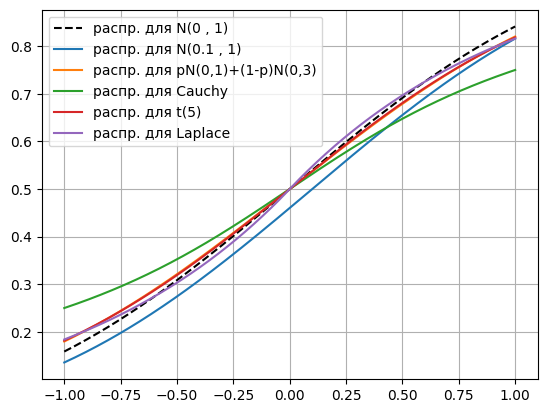

In [ ]:
# Графики функций распределения при гипотезе и альтернативе

xlist = np.linspace(-1, 1, 500)

ylist = [sts.norm.cdf(x, loc = 0, scale = 1) for x in xlist] #значение функции в заданных точках
plt.plot(xlist, ylist, label = 'распр. для N(0 , 1)', color='black', linestyle='--') #график

ylist = [sts.norm.cdf(x, loc = mu, scale = 1) for x in xlist] #значение функции в заданных точках
plt.plot(xlist, ylist, label = 'распр. для N(0.1 , 1)') #график

ylist = [p*sts.norm.cdf(x, loc = 0, scale = 1) + (1-p)*sts.norm.cdf(x, loc=0, scale=3) for x in xlist] #значение функции в заданных точках
plt.plot(xlist, ylist, label ='распр. для pN(0,1)+(1-p)N(0,3)') #график

ylist = [sts.cauchy.cdf(x, loc = 0) for x in xlist] #значение функции в заданных точках
plt.plot(xlist, ylist, label ='распр. для Cauchy') #график

ylist = [sts.t.cdf(x, df = 5, loc = 0) for x in xlist] #значение функции в заданных точках
plt.plot(xlist, ylist, label ='распр. для t(5)') #график

ylist = [sts.laplace.cdf(x, loc = 0, scale = 1) for x in xlist] #значение функции в заданных точках
plt.plot(xlist, ylist, label ='распр. для Laplace') #график

plt.legend()
plt.grid(True)
plt.show() #показывать график


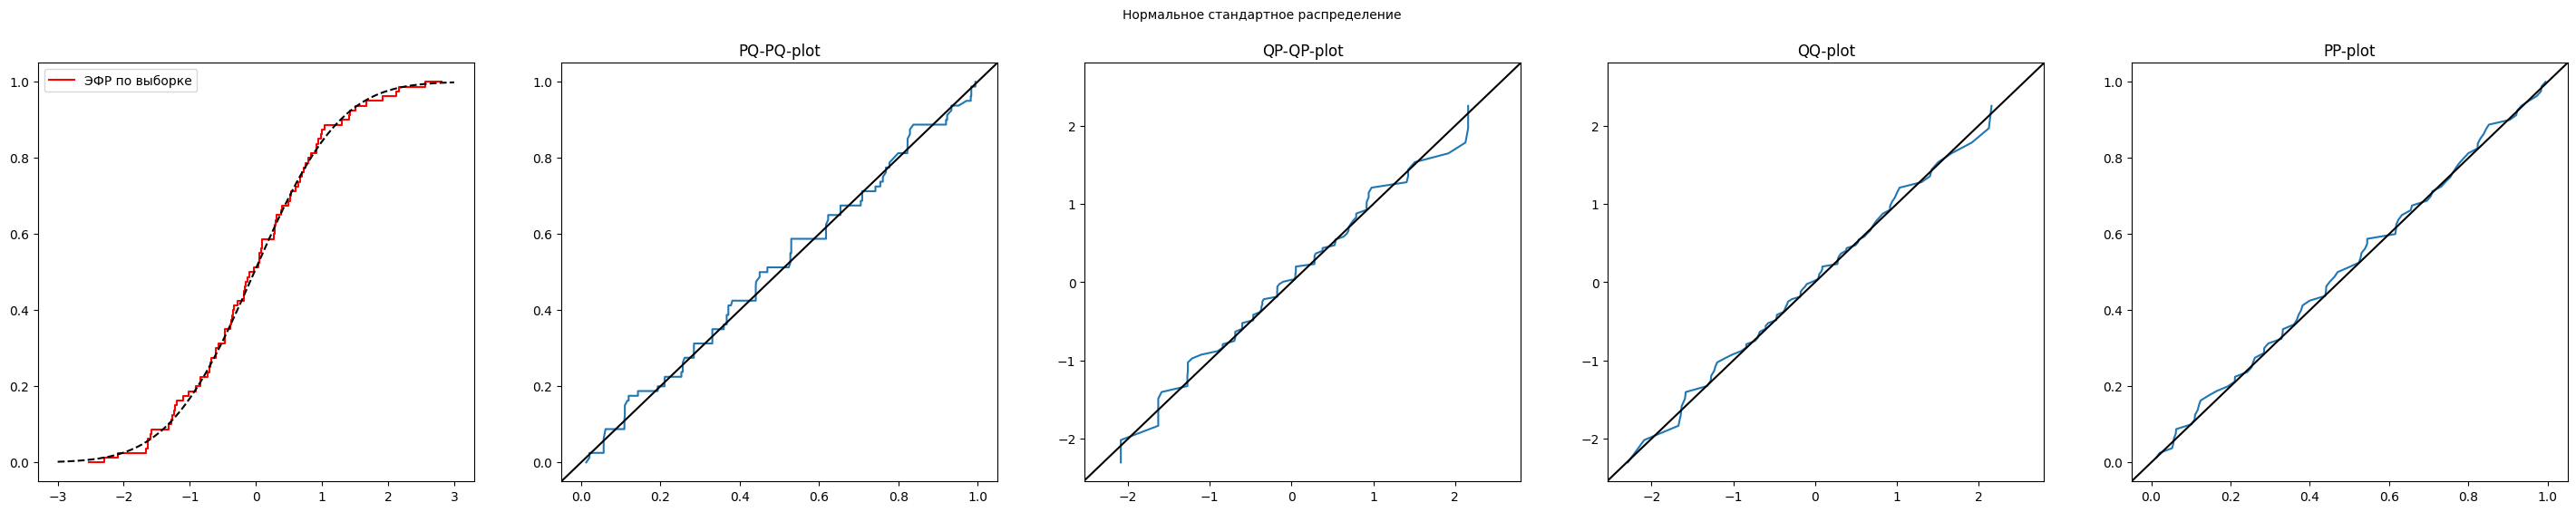

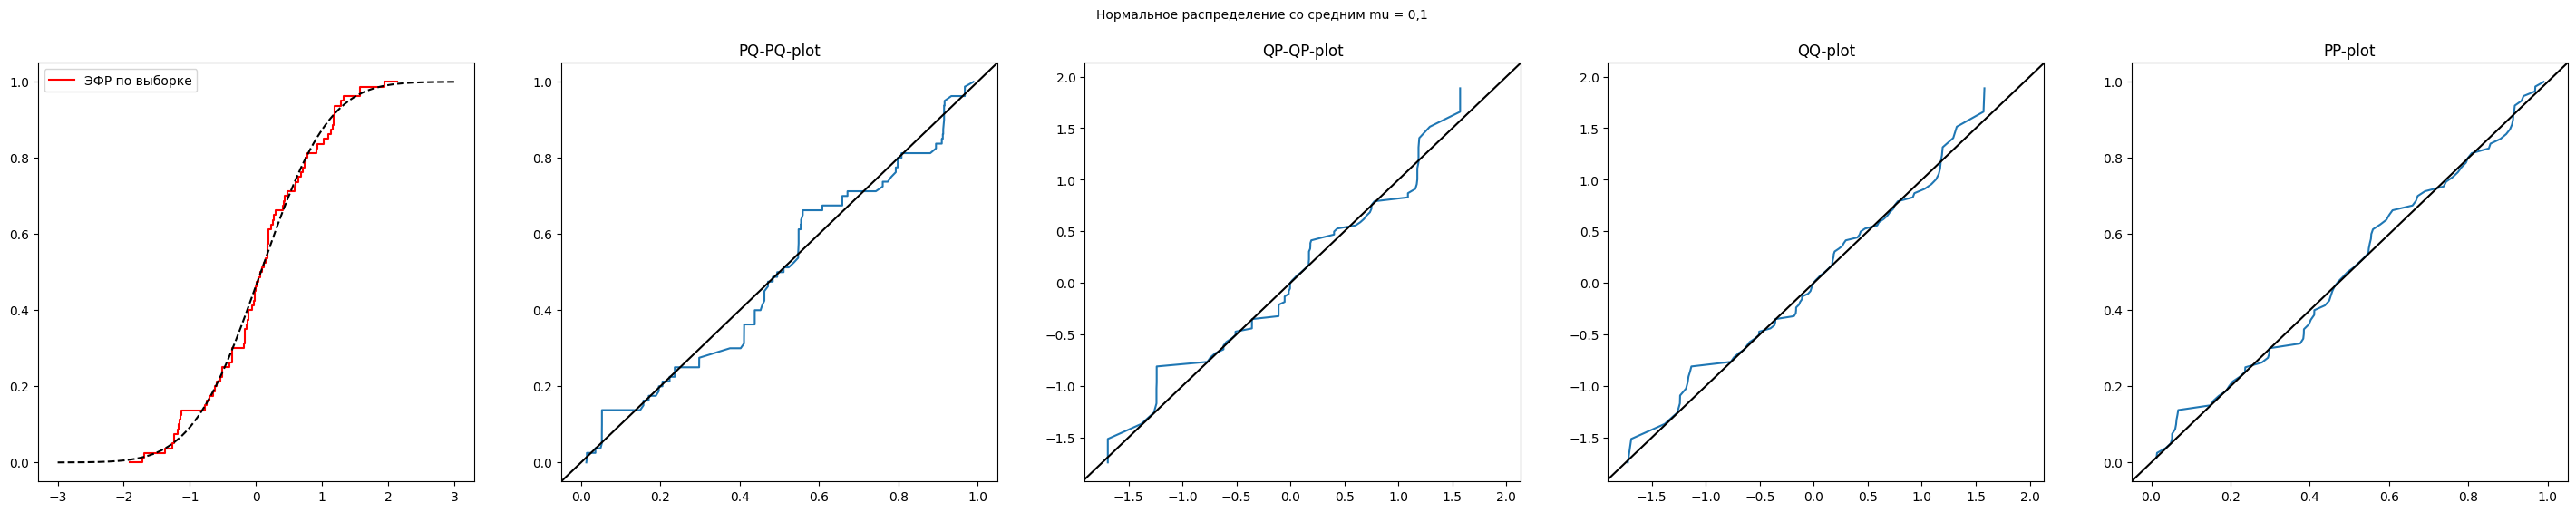

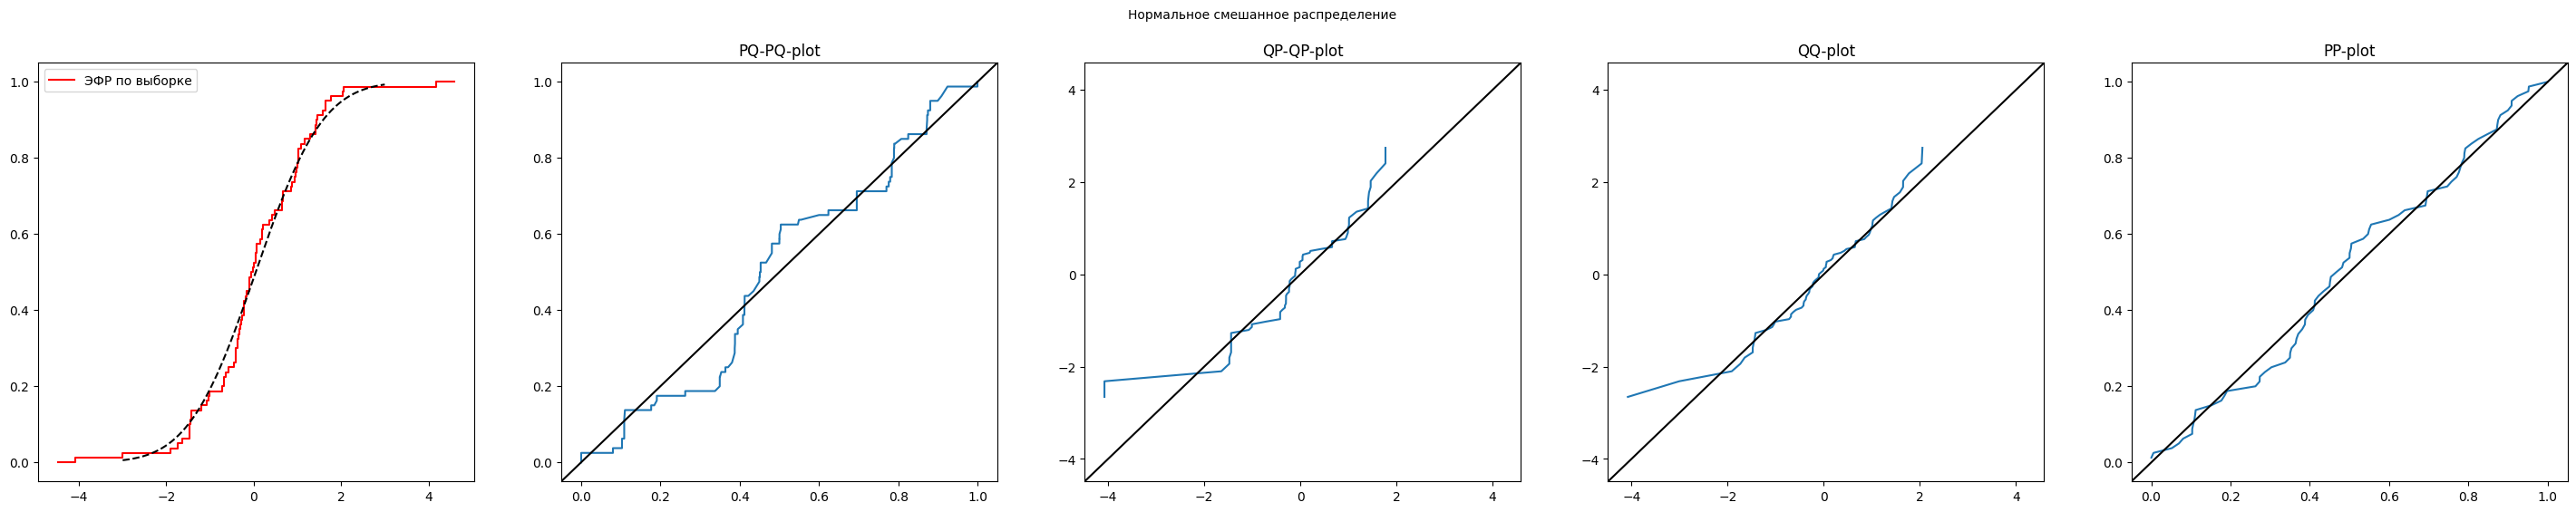

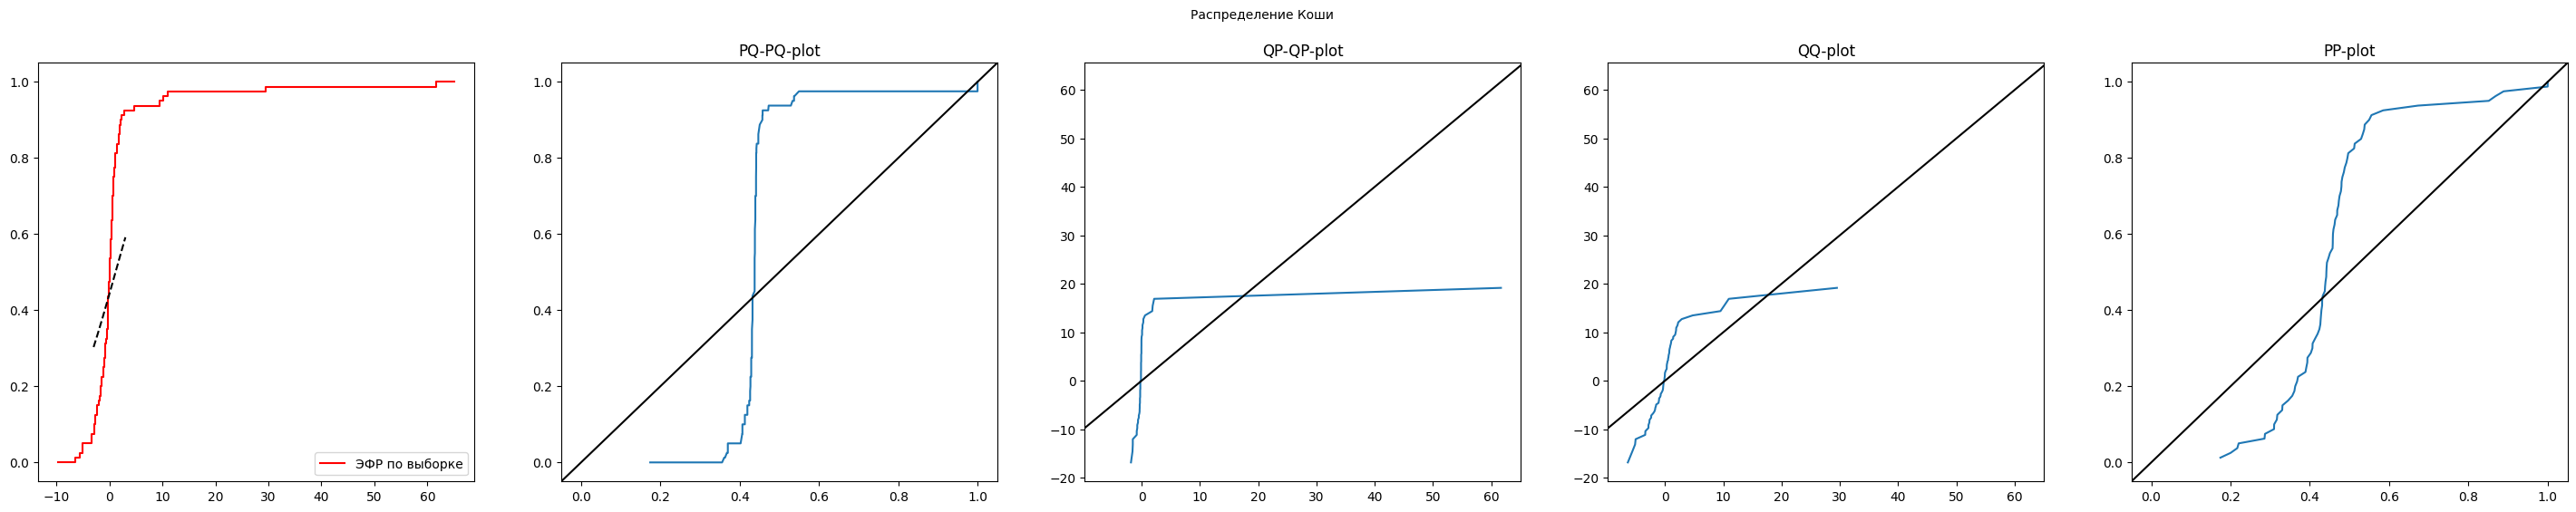

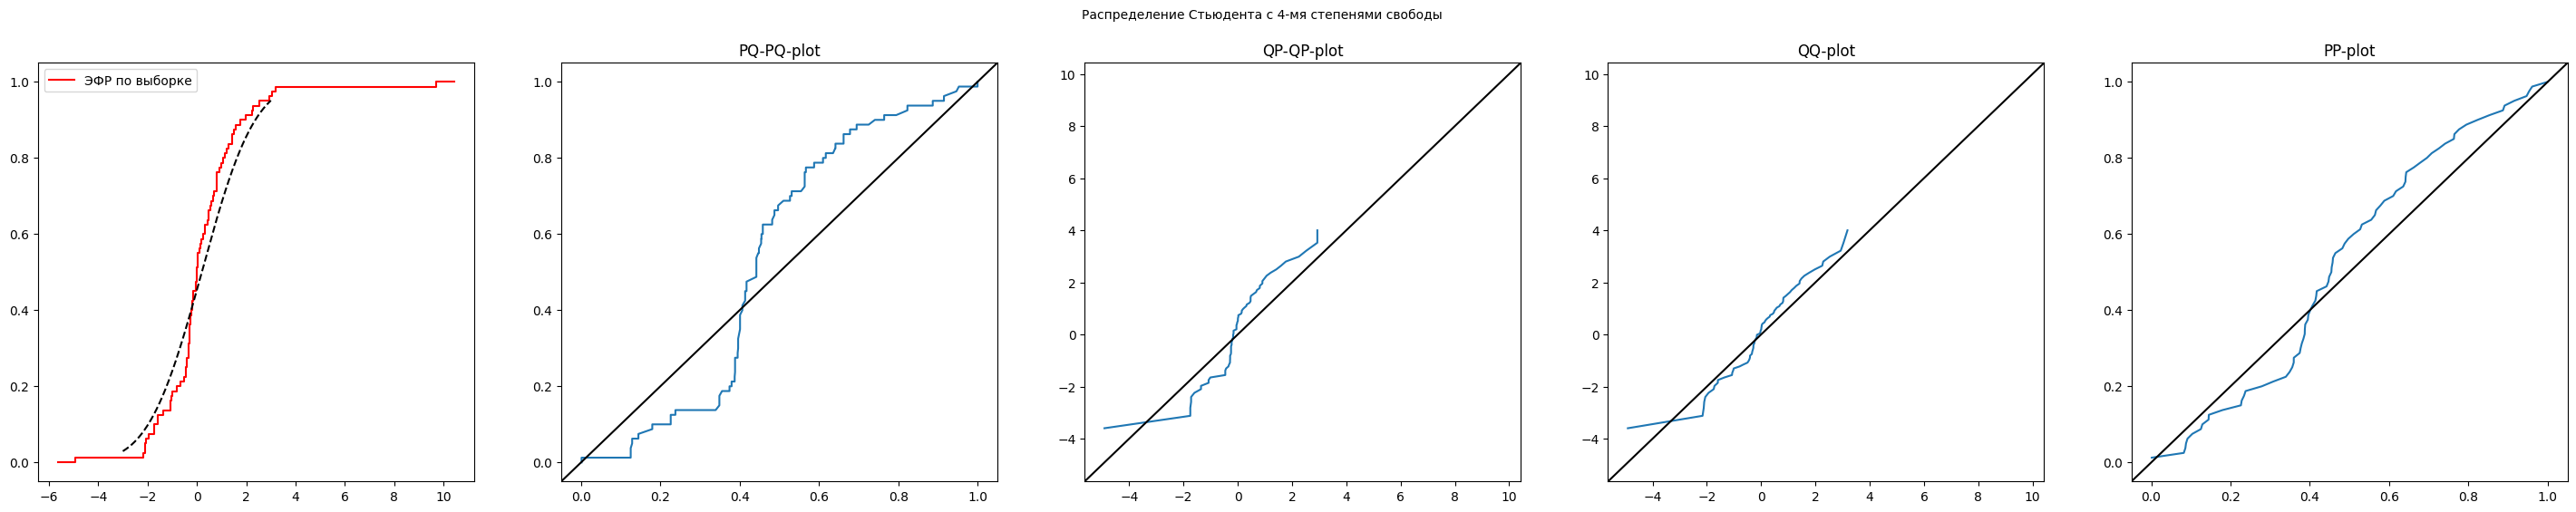

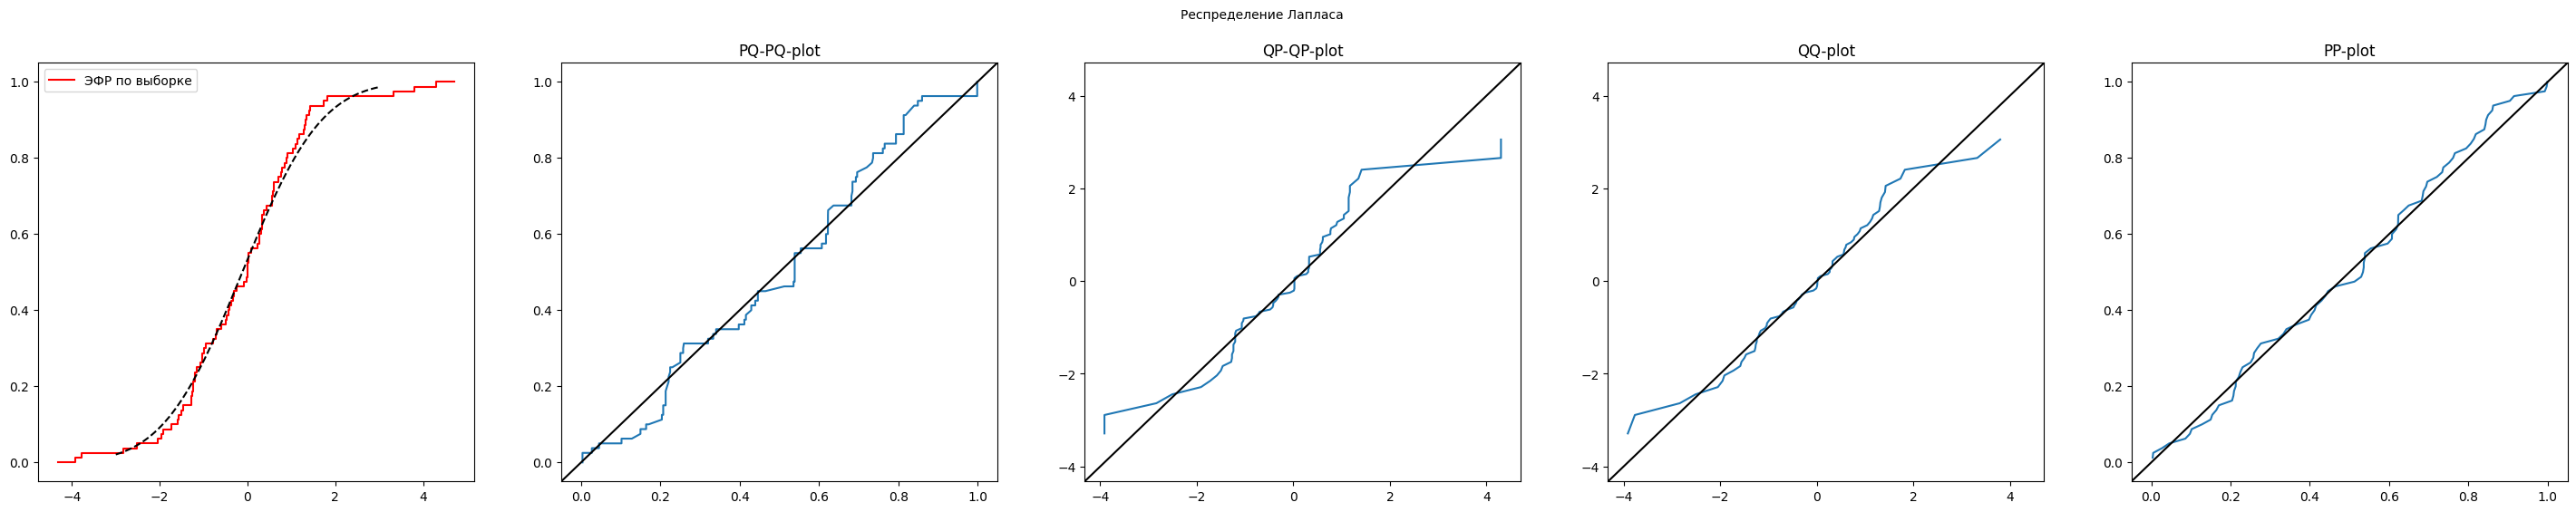

In [ ]:
# попытка сделать PQ-PQ график

n = 80
space = np.linspace(0, 1, 300)

def F_rev(samp, x):
    for i in range(n):
        if x == 0: return samp[0]
        if x > i/n and x <= (i+1)/n: return samp[i]

def F_n(samp, x):
    return np.mean(samp <= x)

for i in range(6):

    samp, mes = sample(i,n)
    samp=np.sort(samp)
    res = sts.ecdf(samp)
    F = sts.norm(loc = np.mean(samp), scale = np.std(samp))

    X = [F.cdf(F_rev(samp, x)) for x in space]
    Y = [F_n(samp, F.ppf(x)) for x in space]
    X1 = [F_rev(samp, F.cdf(x)) for x in samp]
    Y1 = [F.ppf(F_n(samp, x)) for x in samp]

    fig, axes = plt.subplots(1, 5, figsize=(36, 6))
    fig.suptitle(mes, fontsize=10)

    res.cdf.plot(axes[0], color='red', label='ЭФР по выборке')

    s = np.linspace(-3, 3, 300)
    axes[1].set_title('ECDF')
    axes[0].plot(s, F.cdf(s), color='black', linestyle='--')
    axes[0].legend()

    axes[1].plot(X, Y, label = 'PQ-PQ график')
    axes[1].set_title('PQ-PQ-plot')
    axes[1].axline((0, 0), (1, 1), color='black')

    axes[2].set_title('QP-QP-plot')
    axes[2].plot(X1, Y1, label= 'QP-QP график')
    axes[2].axline((samp[0], samp[0]), (samp[n-1], samp[n-1]), color='black')

    axes[3].set_title('QQ-plot')
    axes[3].plot(samp, F.ppf(np.linspace(1/n,1,n)), label= 'Q-Q график')
    axes[3].axline((samp[0], samp[0]), (samp[n-1], samp[n-1]), color='black')

    axes[4].set_title('PP-plot')
    axes[4].plot(F.cdf(samp), np.linspace(1/n,1,n), label= 'P-P график')
    axes[4].axline((0, 0), (1,1), color='black')



In [ ]:
n = 150
N = 100

<ipython-input-2-12a72c548c66>:72: RuntimeWarning: divide by zero encountered in log
  np.log(1 - dist.cdf(sample[l-1-i])))
<ipython-input-2-12a72c548c66>:71: RuntimeWarning: divide by zero encountered in log
  t -= (2*(i+1)-1)/l * (np.log(dist.cdf(sample[i])) +


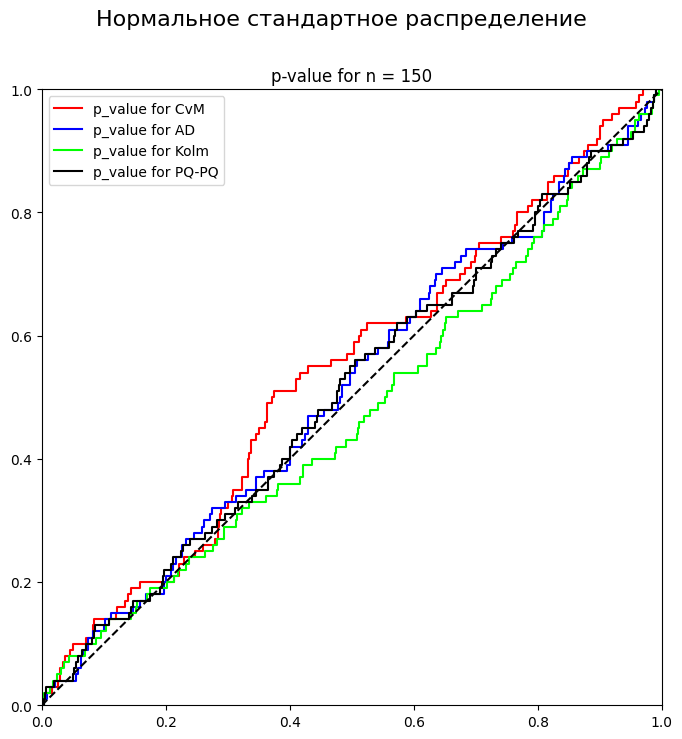

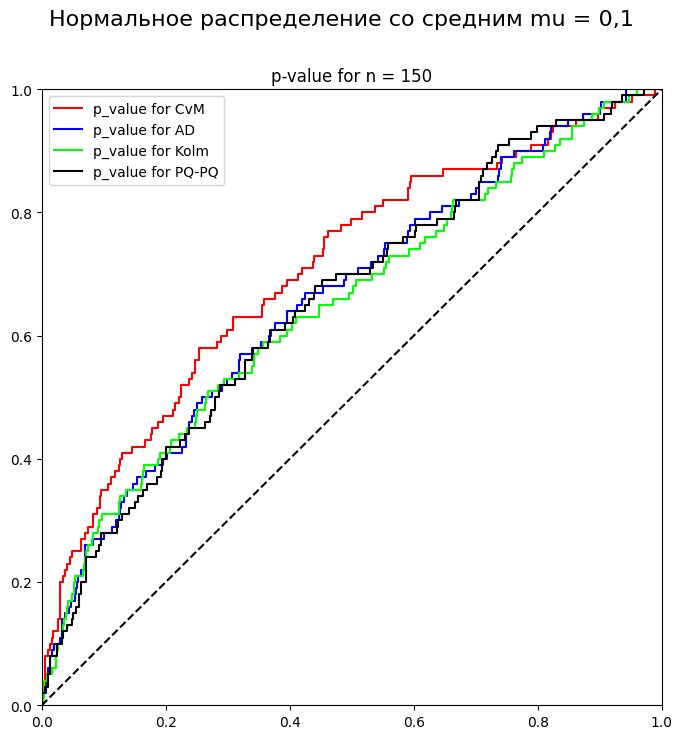

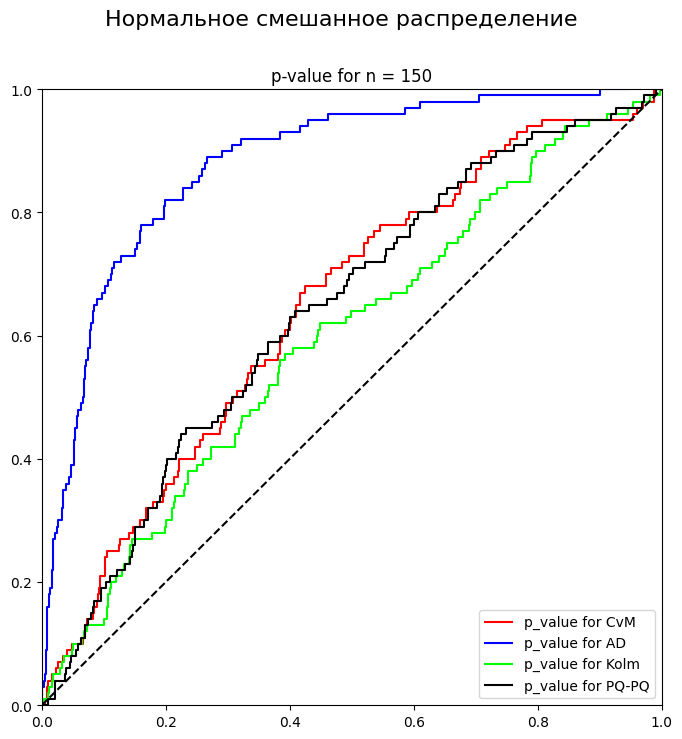

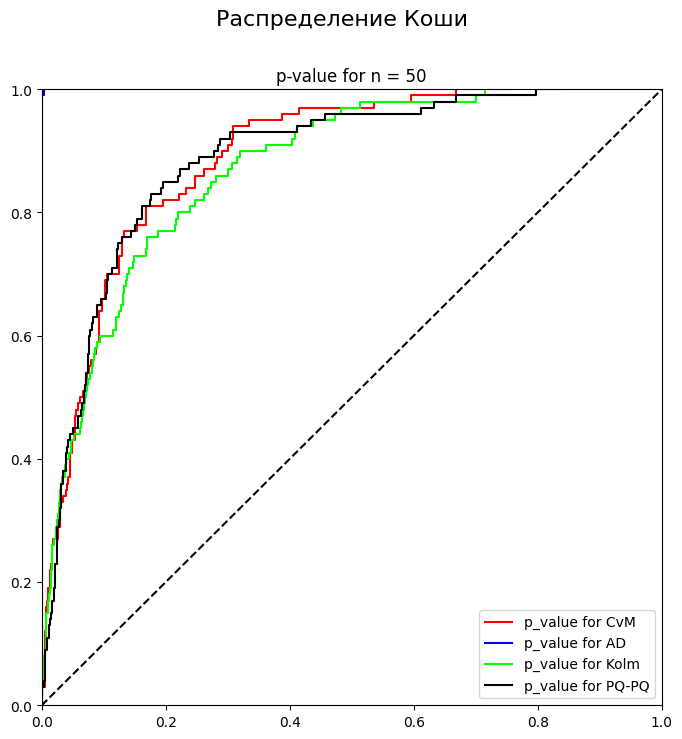

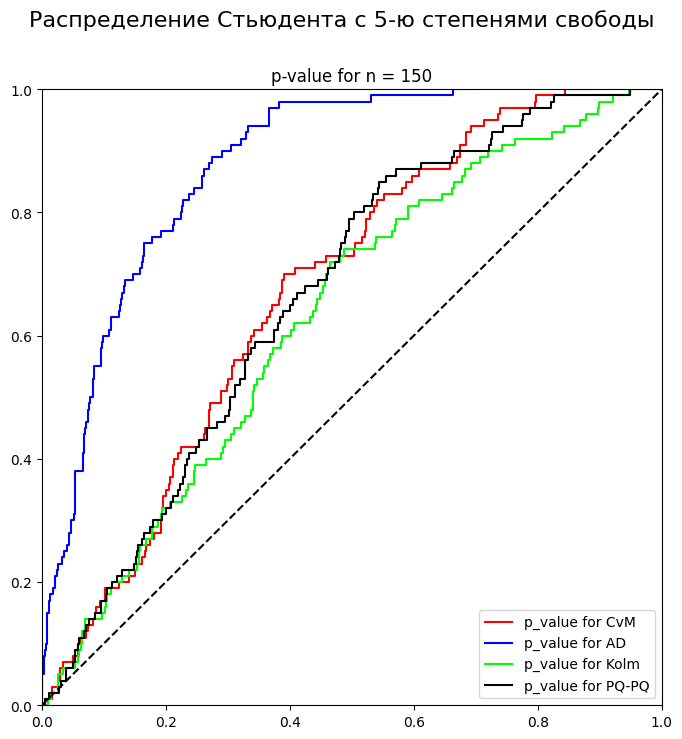

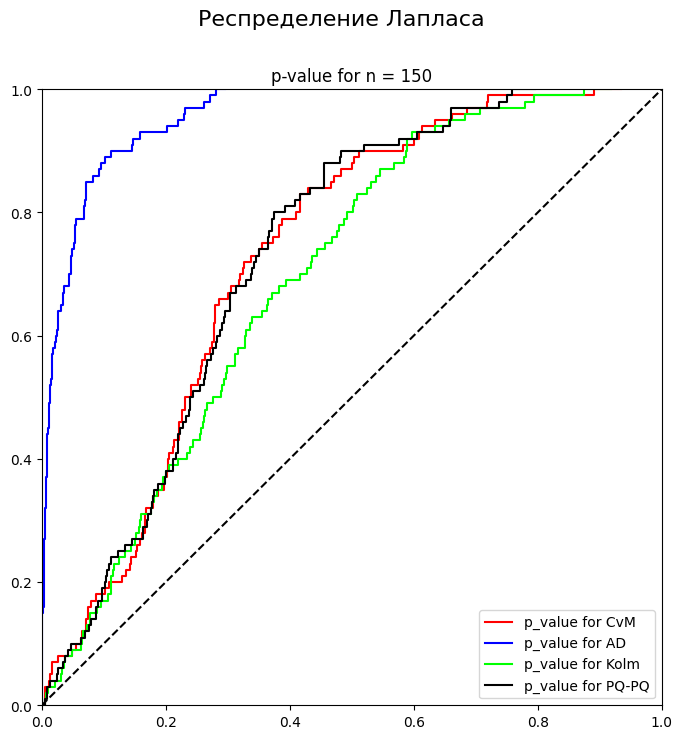

In [ ]:
#сравнение мощности с другими критериями

p_val_cvm = np.zeros(N)
p_val_ad = np.zeros(N)
p_val_colm = np.zeros(N)
p_val_pq_pq = np.zeros(N)

for i in range(6):
    for j in range(N):

        if i == 3: n = 50 # для коши сделал меньше наблюдений, чтобы было видно
        else: n = 150

        X, mes = sample(i)

        tcvm = CvM(X, distribution('normal', loc = 0, scale = 1))
        tad = AD(X, distribution('normal', loc = 0, scale = 1))
        tcolm = Kolm(X, distribution('normal', loc = 0, scale = 1))
        tpq_pq = PQ_PQ(X, distribution('normal', loc = 0, scale = 1))

        p_val_cvm[j] = MK_p_value(tcvm, 'CvM')
        p_val_ad[j] = MK_p_value(tad, 'AD')
        p_val_colm[j] = sts.kstwobign.sf(tcolm)
        p_val_pq_pq[j] = MK_p_value(tpq_pq, 'PQ-PQ')

    fig, axes = plt.subplots(figsize=(8, 8))
    fig.suptitle(mes, fontsize=16)

    res1 = sts.ecdf(p_val_cvm)
    res2 = sts.ecdf(p_val_ad)
    res3 = sts.ecdf(p_val_colm)
    res4 = sts.ecdf(p_val_pq_pq)

    res1.cdf.plot(axes, color='red', label='p_value for CvM')
    res2.cdf.plot(axes, color='blue', label='p_value for AD')
    res3.cdf.plot(axes, color='lime', label='p_value for Kolm')
    res4.cdf.plot(axes, color='black', label='p_value for PQ-PQ')

    axes.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), color='black', linestyle='--')
    axes.set_title(f'p-value for n = {n}')
    axes.set_xlim(0, 1)
    axes.set_ylim(0, 1)
    axes.legend()

In [ ]:
def num(n):
    n = n/5
    if n == 1: return 0, 0
    if n == 2: return 0, 1
    if n == 3: return 0, 2
    if n == 4: return 1, 0
    if n == 6: return 1, 1
    if n == 8: return 1, 2
    else: return -1, -1

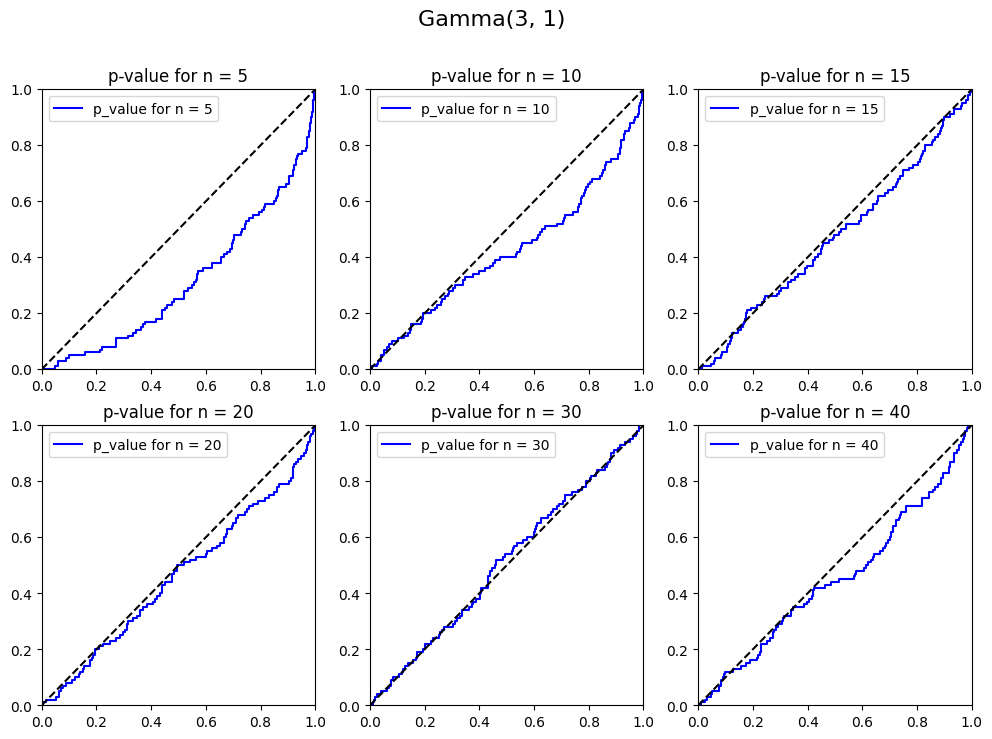

In [ ]:
#2. Сходимость к предельному распределению при малых n

#в statistic.csv методом Монте-Карло созданы значения при гипотезе при n = 1000

n_set = [5, 10, 15, 20, 30, 40]
N = 100
p_val_pq_pq = np.zeros(N)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Gamma(3, 1)', fontsize=16)

for n in n_set:

        for i in range(N):
                X  = sts.gamma.rvs(a = 3, loc = 0, scale = 1, size = n)

                tpq_pq = PQ_PQ(X, distribution('gamma', a = 3, loc = 0, scale = 1))

                p_val_pq_pq[i] = MK_p_value(tpq_pq, 'PQ-PQ')

        res = sts.ecdf(p_val_pq_pq)

        res.cdf.plot(axes[num(n)], color='blue', label=f'p_value for n = {n}')
        axes[num(n)].plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), color='black', linestyle='--')
        axes[num(n)].set_title(f'p-value for n = {n}')
        axes[num(n)].set_xlim(0, 1)
        axes[num(n)].set_ylim(0, 1)
        axes[num(n)].legend()



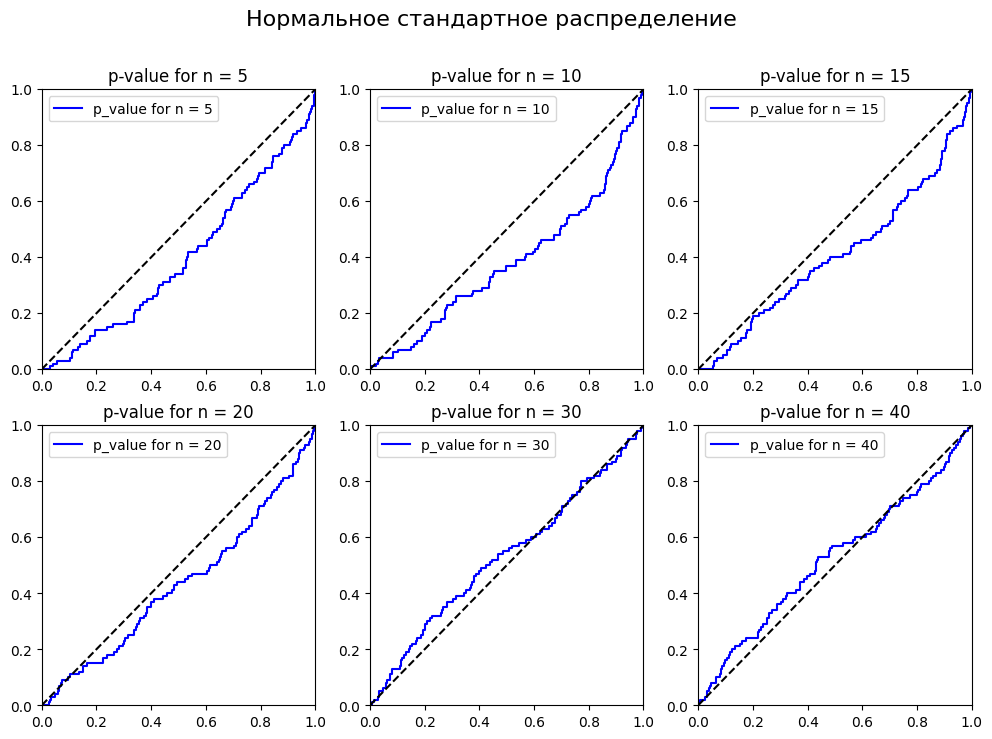

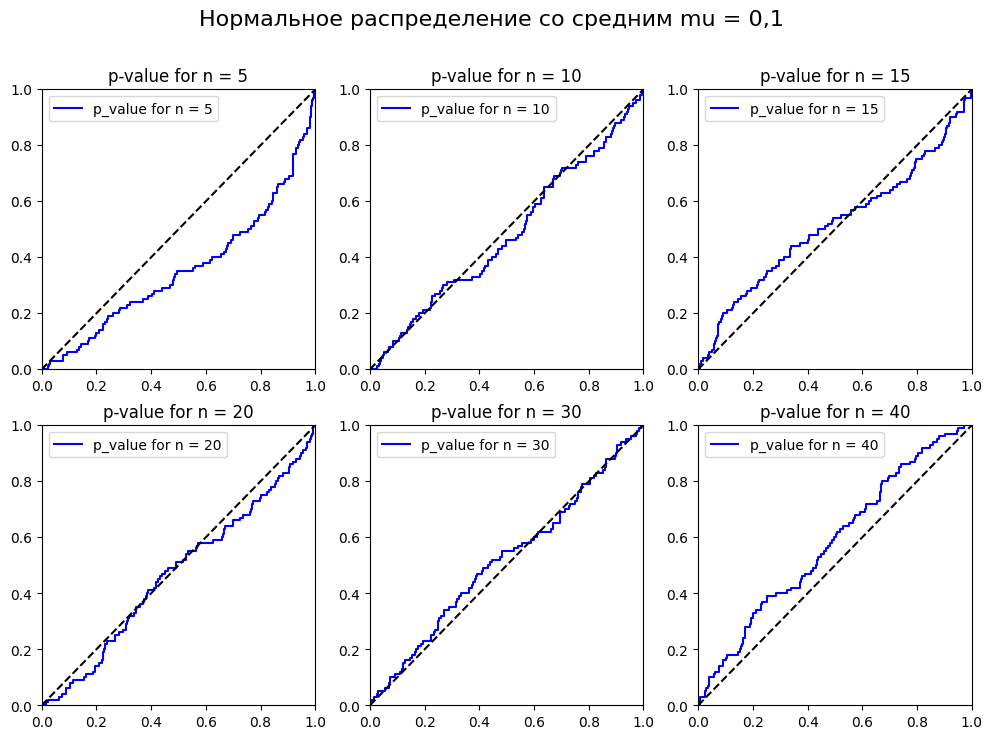

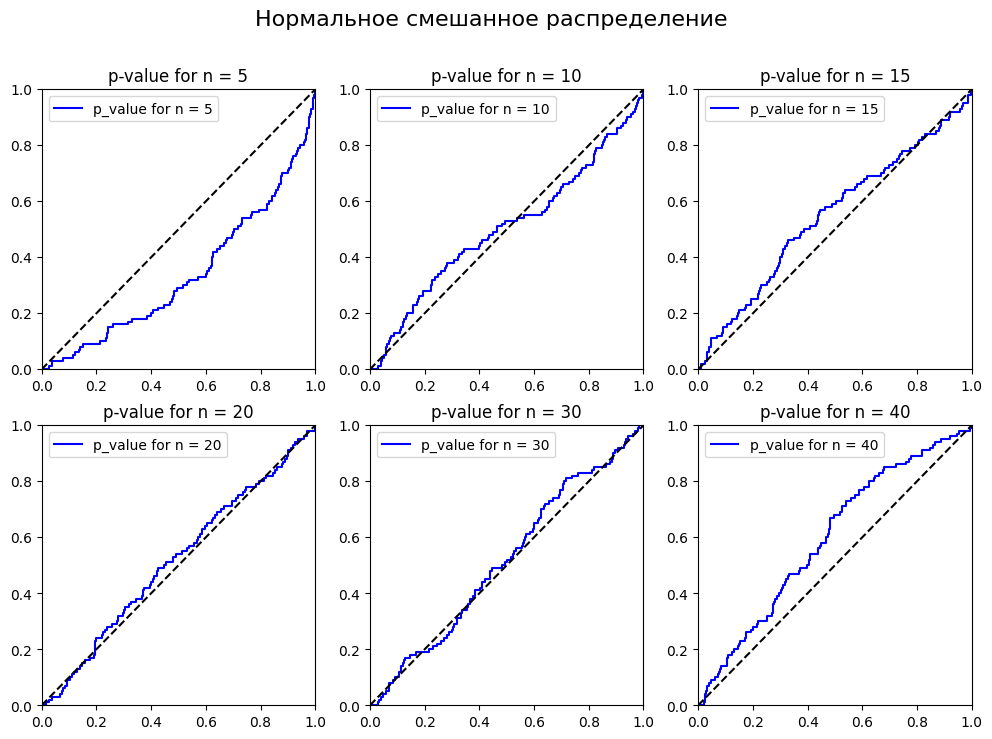

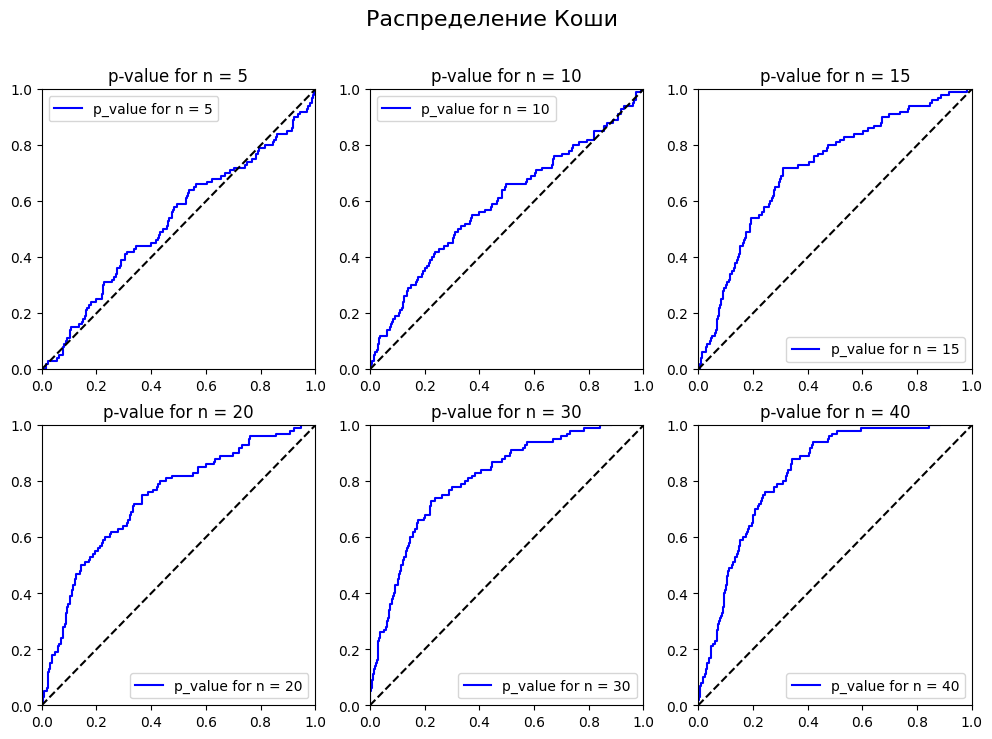

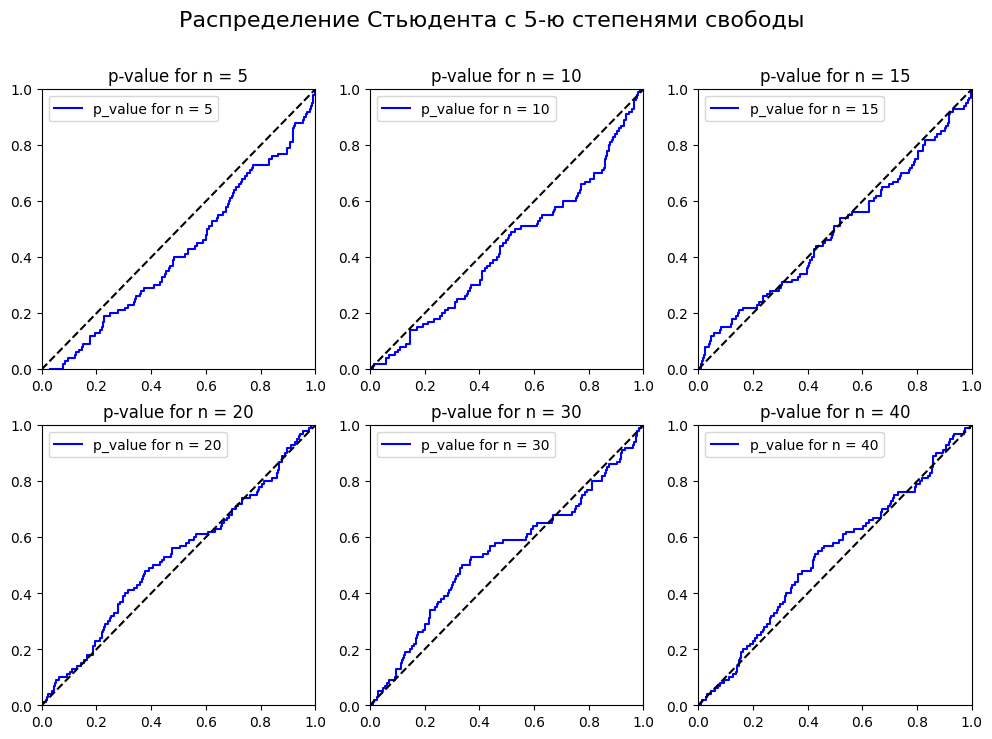

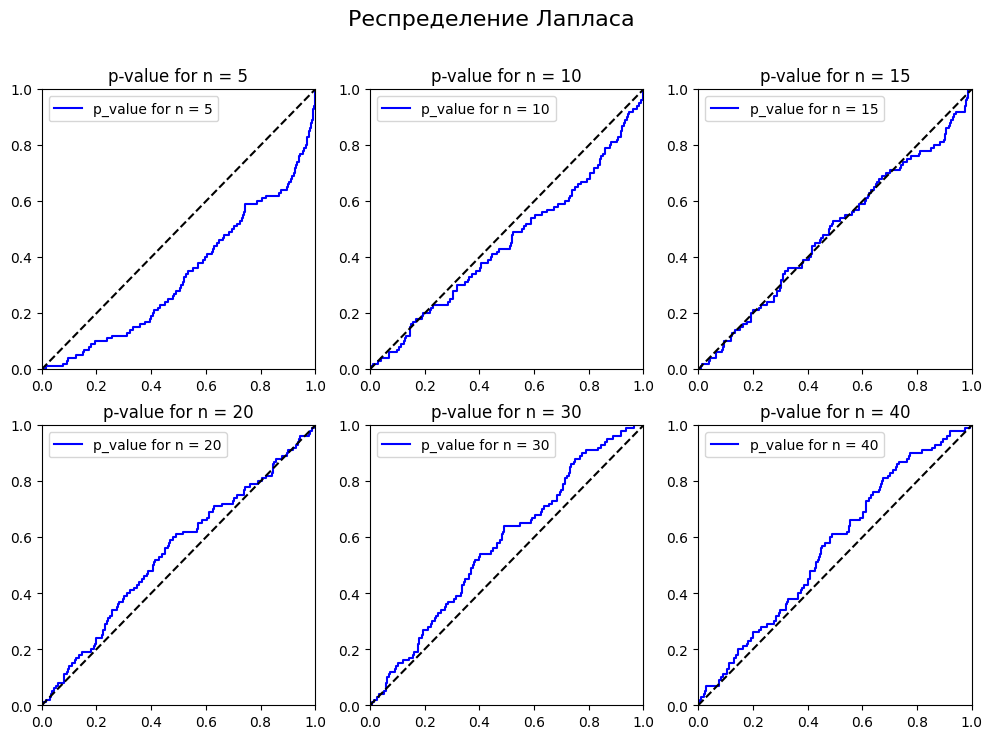

In [ ]:
#3. Альтернатива при малых n

n_set = [5, 10, 15, 20, 30, 40]
N = 100
p_val_pq_pq = np.zeros(N)

for j in range(6):

        fig, axes = plt.subplots(2, 3, figsize=(12, 8))

        for n in n_set:

                for i in range(N):

                        X, mes = sample(j)

                        tpq_pq = PQ_PQ(X, distribution('normal', a = 3, loc = 0, scale = 1))

                        p_val_pq_pq[i] = MK_p_value(tpq_pq, 'PQ-PQ')

                res = sts.ecdf(p_val_pq_pq)

                res.cdf.plot(axes[num(n)], color='blue', label=f'p_value for n = {n}')
                axes[num(n)].plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), color='black', linestyle='--')
                axes[num(n)].set_title(f'p-value for n = {n}')
                axes[num(n)].set_xlim(0, 1)
                axes[num(n)].set_ylim(0, 1)
                axes[num(n)].legend()

        fig.suptitle(mes, fontsize=16)

